In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path="../backend/.env")

DATABASE_URL = os.getenv("DATABASE_URL")
engine = create_engine(DATABASE_URL)

# for testing
query = "SELECT * FROM students LIMIT 5;"
df_students = pd.read_sql(query, engine)

df_students.head()

,id,user_id,student_id_number,birth_date,cohort_id,enrollment_status,created_at
0,1,1,STU-100001,2002-03-05,1,ACTIVE,2026-06-04 17:09:52.576612
1,2,2,STU-100002,2007-10-14,2,ACTIVE,2026-06-04 17:09:52.576653
2,3,3,STU-100003,2005-05-18,3,ACTIVE,2026-06-04 17:09:52.576686
3,4,4,STU-100004,2006-09-13,3,ACTIVE,2026-06-04 17:09:52.576716
4,5,5,STU-100005,2008-05-09,2,ACTIVE,2026-06-04 17:09:52.576744


Statistiques Descriptives des Notes :


count    8000.000000
mean       11.097155
std         4.315074
min         0.000000
25%         9.350000
50%        11.740000
75%        13.950000
max        18.830000
Name: score, dtype: float64

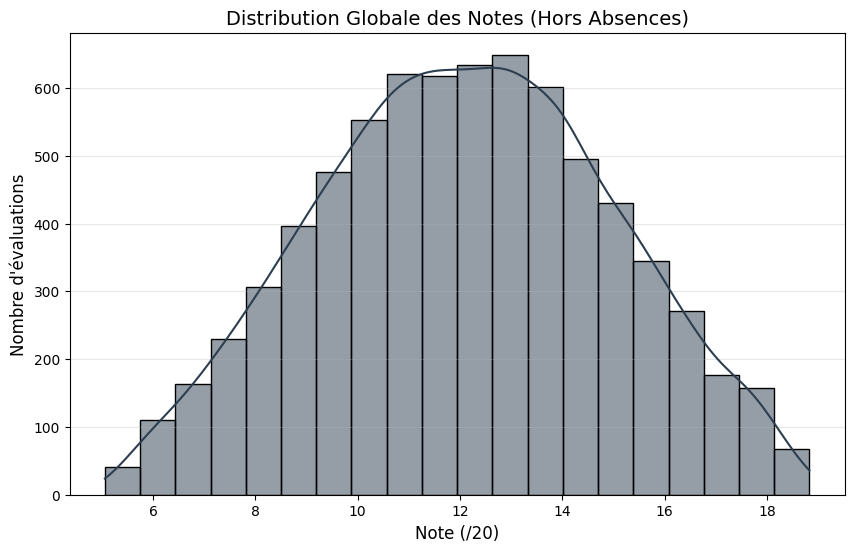

In [10]:
# I'll fetch the grades data by joining the relevant tables
query_grades = """
SELECT g.score, g.is_absent, e.type, m.name as module_name
FROM grades g
JOIN evaluations e ON g.evaluation_id = e.id
JOIN cohort_modules cm ON e.cohort_module_id = cm.id
JOIN modules m ON cm.module_id = m.id;
"""
df_grades = pd.read_sql(query_grades, engine)

# I'll display a basic statistics (Mean, Min, Max, etc.)
print("Statistiques Descriptives des Notes :")
display(df_grades['score'].describe())

# for visualizion of the distribution of all grades
plt.figure(figsize=(10, 6))
sns.histplot(data=df_grades[df_grades['is_absent'] == False], x='score', bins=20, kde=True, color='#2c3e50')
plt.title('Distribution Globale des Notes (Hors Absences)', fontsize=14)
plt.xlabel('Note (/20)', fontsize=12)
plt.ylabel('Nombre d\'évaluations', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

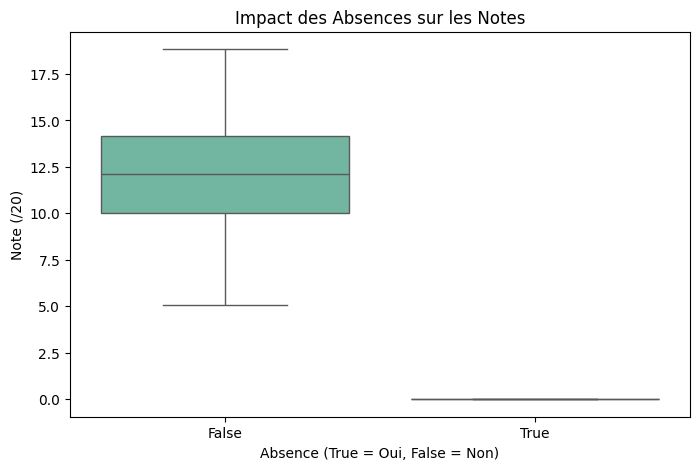

In [13]:
# Visualizing the impact of absences on student scores to detect correlations.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_grades, x='is_absent', y='score', hue='is_absent', palette='Set2', legend=False)
plt.title('Impact des Absences sur les Notes')
plt.xlabel('Absence (True = Oui, False = Non)')
plt.ylabel('Note (/20)')
plt.show()